# 03 - Dataset Loader
Builds the PyTorch `Dataset` class, applies augmentation transforms, and verifies the DataLoader.

**What this notebook does:**
- Defines a custom `DocumentDataset` class that reads images from the split folders
- Applies different transforms for train (augmentation) vs val/test (no augmentation)
- Verifies a batch looks correct before we start training
- Saves the class map so all future notebooks use the same label→name mapping

In [90]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import sys

In [91]:
GLOBAL_PATH = str(Path.cwd().parent.parent / "global")
if GLOBAL_PATH not in sys.path:
    sys.path.append(GLOBAL_PATH)
%reload_ext autoreload
%autoreload 2
import config
import utils

In [92]:
print(f"Device : {config.DEVICE} - {config.DEVICE_NAME}")

Device : cuda - NVIDIA GeForce RTX 3070


In [93]:
train_transforms = utils.get_transforms(True)
val_test_transforms = utils.get_transforms()
print(f"Train transforms : \t{len(train_transforms.transforms)} steps")
print(f"Val/test transforms : \t{len(val_test_transforms.transforms)} steps")

Train transforms : 	9 steps
Val/test transforms : 	3 steps


In [94]:
train_dataset = utils.EcuadorianDocumentsDataset(config.TRAIN_DIR, config.CLASSES, transform=train_transforms)
val_dataset   = utils.EcuadorianDocumentsDataset(config.VAL_DIR, config.CLASSES, transform=val_test_transforms)
test_dataset  = utils.EcuadorianDocumentsDataset(config.TEST_DIR, config.CLASSES, transform=val_test_transforms)

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Test samples  : {len(test_dataset)}")
print()
print("Train class counts:", train_dataset.class_counts())
print("Val class counts  :", val_dataset.class_counts())
print("Test class counts :", test_dataset.class_counts())

Train samples : 231
Val samples   : 49
Test samples  : 51

Train class counts: {'id_new': 22, 'id_old': 44, 'passport': 67, 'unknown': 98}
Val class counts  : {'id_new': 5, 'id_old': 9, 'passport': 14, 'unknown': 21}
Test class counts : {'id_new': 5, 'id_old': 10, 'passport': 15, 'unknown': 21}


In [95]:
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,          # shuffle every epoch — important for training
    pin_memory=torch.cuda.is_available(),  # faster GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,         # no shuffle for eval — consistent order
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 15
Val batches   : 4
Test batches  : 4


In [96]:
images, labels = next(iter(train_loader))

print(f"Batch shape  : {images.shape}")
print(f"  Expected   : torch.Size([{config.BATCH_SIZE}, 3, {config.IMAGE_SIZE}, {config.IMAGE_SIZE}])")
print(f"Dtype        : {images.dtype}")
print(f"Value range  : [{images.min():.3f}, {images.max():.3f}]")
print(f"Labels       : {labels.tolist()}")
print(f"Label names  : {[list(config.CLASSES.keys())[l] for l in labels.tolist()]}")

Batch shape  : torch.Size([16, 3, 224, 224])
  Expected   : torch.Size([16, 3, 224, 224])
Dtype        : torch.float32
Value range  : [-2.118, 2.640]
Labels       : [2, 1, 2, 3, 3, 3, 1, 3, 3, 1, 3, 1, 1, 0, 3, 3]
Label names  : ['passport', 'id_old', 'passport', 'unknown', 'unknown', 'unknown', 'id_old', 'unknown', 'unknown', 'id_old', 'unknown', 'id_old', 'id_old', 'id_new', 'unknown', 'unknown']


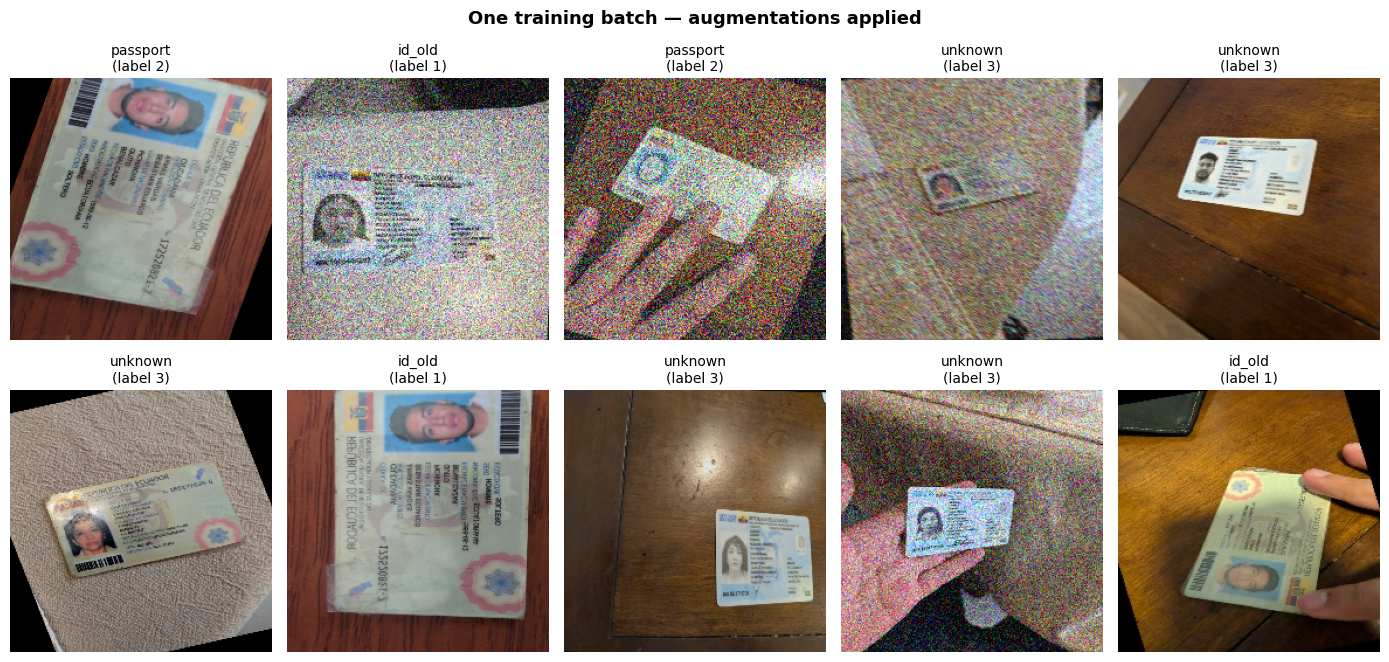

In [97]:
def denormalize(tensor, mean=config.IMAGENET_MEAN, std=config.IMAGENET_STD):
    """Reverses ImageNet normalization for display purposes."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

label_names = {v: k for k, v in config.CLASSES.items()}
n_show      = min(10, len(images))

fig, axes = plt.subplots(2, 5, figsize=(14, 7))
axes_flat = axes.flatten()

for i in range(n_show):
    img_display = denormalize(images[i]).permute(1, 2, 0).numpy()
    axes_flat[i].imshow(img_display)
    axes_flat[i].set_title(
        f"{label_names[labels[i].item()]}\n(label {labels[i].item()})",
        fontsize=10
    )
    axes_flat[i].axis("off")

for j in range(n_show, len(axes_flat)):
    axes_flat[j].axis("off")

fig.suptitle("One training batch — augmentations applied", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

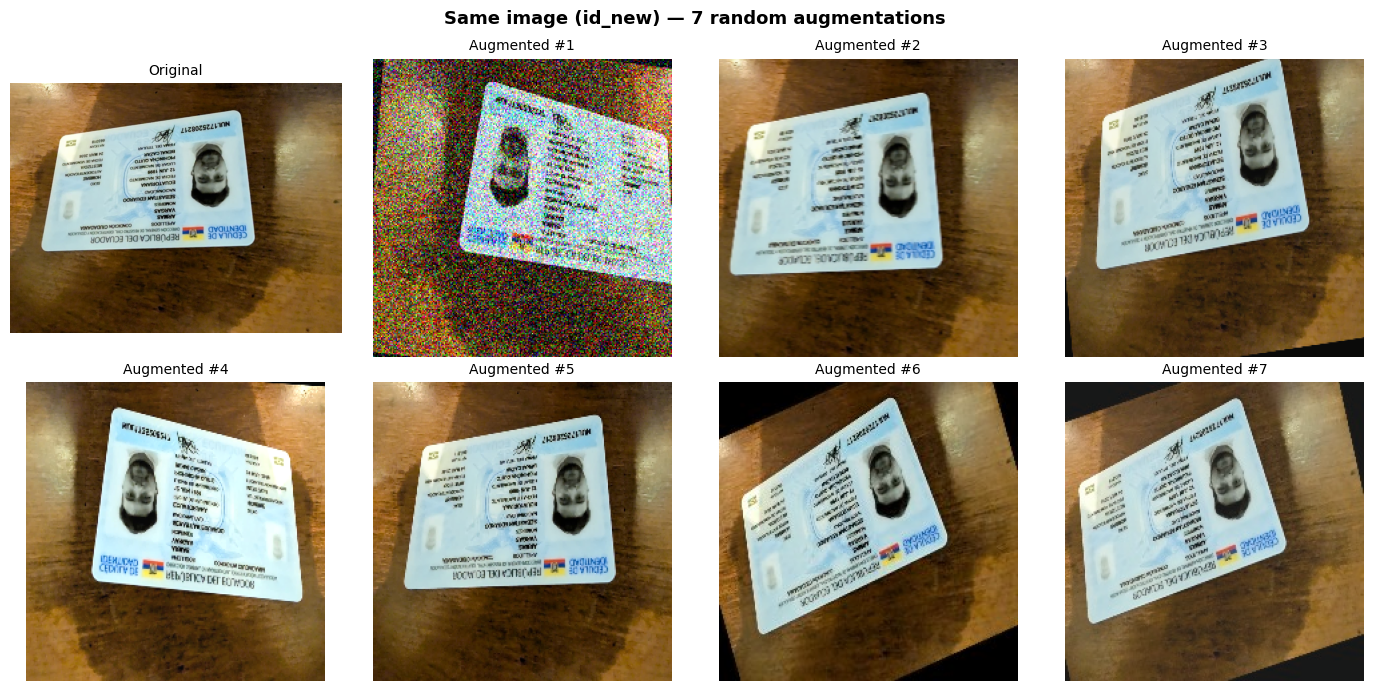

In [98]:
# Pick first image from train set
sample_path, sample_label = train_dataset.samples[0]
sample_np   = np.array(Image.open(sample_path).convert("RGB"))
label_name  = list(config.CLASSES.keys())[sample_label]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes_flat = axes.flatten()

# First slot: original (no augmentation)
axes_flat[0].imshow(sample_np)
axes_flat[0].set_title("Original", fontsize=10)
axes_flat[0].axis("off")

# Next 7 slots: 7 different random augmentations of the same image
for i in range(1, 8):
    augmented  = train_transforms(image=sample_np)["image"]
    display    = denormalize(augmented).permute(1, 2, 0).numpy()
    axes_flat[i].imshow(display)
    axes_flat[i].set_title(f"Augmented #{i}", fontsize=10)
    axes_flat[i].axis("off")

fig.suptitle(
    f"Same image ({label_name}) — 7 random augmentations",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [99]:
class_map = {
    "label_to_name": {str(v): k for k, v in config.CLASSES.items()},
    "name_to_label": config.CLASSES,
    "num_classes"  : len(config.CLASSES),
    "image_size"   : config.IMAGE_SIZE,
    "imagenet_mean": config.IMAGENET_MEAN,
    "imagenet_std" : config.IMAGENET_STD,
}

save_path = config.PROJECT_ROOT / "class_map.json"
with open(save_path, "w") as f:
    json.dump(class_map, f, indent=2)

print(f"Saved: {save_path}")
print(json.dumps(class_map, indent=2))

Saved: D:\Aprender\Projects\ecuadorian-id-classifier\class_map.json
{
  "label_to_name": {
    "0": "id_new",
    "1": "id_old",
    "2": "passport",
    "3": "unknown"
  },
  "name_to_label": {
    "id_new": 0,
    "id_old": 1,
    "passport": 2,
    "unknown": 3
  },
  "num_classes": 4,
  "image_size": 224,
  "imagenet_mean": [
    0.485,
    0.456,
    0.406
  ],
  "imagenet_std": [
    0.229,
    0.224,
    0.225
  ]
}
